<a href="https://colab.research.google.com/github/moongoldpk/Predicting-Customer-Churn-in-the-Telecom-Industry-Using-Machine-Learning-Algorithms/blob/main/Copy_of_Telco_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Customer Churn in the Telecom Industry
## Using Machine Learning Algorithms

**Dataset:** IBM Watson Telco Customer Churn (7,043 records · 20 features · 26.5% churn rate)  
**University:** Leeds Trinity University — COM7016 MSc Project


## 1.  Project Overview

This notebook implements a complete ML pipeline to predict customer churn in the telecom industry using the IBM Watson Telco Customer Churn dataset. It covers data loading, exploratory data analysis with 12 visualizations, preprocessing, model training (Logistic Regression, Decision Tree, Random Forest, XGBoost), evaluation, and best-model export aligned to the COM7016 MSc project requirements at Leeds Trinity University.


## 2.  Environment Setup

### 2.1  Required Libraries

In [ ]:
# Install required libraries (run once if needed)
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost joblib jupyter

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib

# Output directories
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'xtick.labelsize': 10,
                     'ytick.labelsize': 10})

print("✅  All libraries imported successfully.")
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}  |  seaborn {sns.__version__}")


✅  All libraries imported successfully.
   pandas 2.2.2  |  numpy 2.0.2  |  seaborn 0.13.2


## 3.  Dataset Column Reference

| Column Name | Data Type | Unique Values / Notes | Preprocessing Action |
|---|---|---|---|
| gender | Categorical | Female, Male | `get_dummies()` — `drop_first=True` |
| SeniorCitizen | Integer | 0 or 1 | Use as-is (already numeric) |
| Partner | Yes/No | Yes, No | Map: Yes→1, No→0 |
| Dependents | Yes/No | Yes, No | Map: Yes→1, No→0 |
| tenure | Integer | 0–72 months | StandardScaler |
| PhoneService | Yes/No | Yes, No | Map: Yes→1, No→0 |
| MultipleLines | Categorical | No, Yes, No phone service | `get_dummies()` — 3 categories |
| InternetService | Categorical | DSL, Fiber optic, No | `get_dummies()` — 3 categories |
| OnlineSecurity | Categorical | No, Yes, No internet service | `get_dummies()` — 3 categories |
| OnlineBackup | Categorical | No, Yes, No internet service | `get_dummies()` — 3 categories |
| DeviceProtection | Categorical | No, Yes, No internet service | `get_dummies()` — 3 categories |
| TechSupport | Categorical | No, Yes, No internet service | `get_dummies()` — 3 categories |
| StreamingTV | Categorical | No, Yes, No internet service | `get_dummies()` — 3 categories |
| StreamingMovies | Categorical | No, Yes, No internet service | `get_dummies()` — 3 categories |
| Contract | Categorical | Month-to-month, One year, Two year | `get_dummies()` — 3 categories |
| PaperlessBilling | Yes/No | Yes, No | Map: Yes→1, No→0 |
| PaymentMethod | Categorical | 4 payment methods | `get_dummies()` — 4 categories |
| MonthlyCharges | Float | 18.25 – 118.75 | StandardScaler |
| TotalCharges | **STRING ⚠** | Stored as text — has 11 blank entries | `pd.to_numeric(errors='coerce')` → `fillna(median)` → StandardScaler |
| Churn | Yes/No | No=5174, Yes=1869 **(TARGET)** | Map: Yes→1, No→0 — this is **y** |

> ⚠️ **Note:** `TotalCharges` is stored as a STRING with 11 blank entries. Use `pd.to_numeric(df['TotalCharges'], errors='coerce')` then `fillna(median)` before scaling.


## Step 1 — Data Loading & Inspection

In [ ]:
def load_data(filepath):
    """Load dataset and print a full console inspection report."""
    df = pd.read_csv(filepath)

    print("=" * 60)
    print("DATASET SHAPE")
    print("=" * 60)
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    assert df.shape == (7068, 21), f"Unexpected shape: {df.shape}"

    print("\n" + "=" * 60)
    print("FIRST 5 ROWS")
    print("=" * 60)
    display(df.head(5))

    print("\n" + "=" * 60)
    print("COLUMN INFO / DTYPES")
    print("=" * 60)
    print(df.dtypes.to_string())

    print("\n" + "=" * 60)
    print("MISSING VALUES (null counts)")
    print("=" * 60)
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.sum() > 0
          else "No null values (TotalCharges blanks are empty strings, not NaN)")

    print("\n" + "=" * 60)
    print("CHURN DISTRIBUTION")
    print("=" * 60)
    print(df['Churn'].value_counts().to_string())
    print()
    print(df['Churn'].value_counts(normalize=True).map('{:.1%}'.format).to_string())

    print("\n" + "=" * 60)
    print("DESCRIPTIVE STATISTICS")
    print("=" * 60)
    display(df.describe())

    return df


DATA_PATH = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df_raw = load_data(DATA_PATH)


DATASET SHAPE
Rows: 7068, Columns: 21

FIRST 5 ROWS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



COLUMN INFO / DTYPES
customerID           object
gender               object
SeniorCitizen       float64
Partner              object
Dependents           object
tenure              float64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object

MISSING VALUES (null counts)
customerID          25
gender              25
SeniorCitizen       25
Partner             25
Dependents          25
tenure              25
PhoneService        25
MultipleLines       25
InternetService     25
OnlineSecurity      25
OnlineBackup        25
DeviceProtection    25
TechSupport         25
StreamingTV         25
StreamingMovies     25
Contract       

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 5.  Visualizations — Complete Specification

## Step 2 — EDA (run_eda)

All 12 visualizations are generated below and saved to `outputs/plots/`. `plt.show()` is never called — all figures use `savefig()` followed by `display()` to render inline.

In [ ]:
def save_fig(filename):
    """Save current figure and display it inline."""
    path = f'outputs/plots/{filename}'
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Saved → {path}")


### Visualization 1 — Churn Class Distribution
**Chart Type:** Bar chart with count + percentage labels

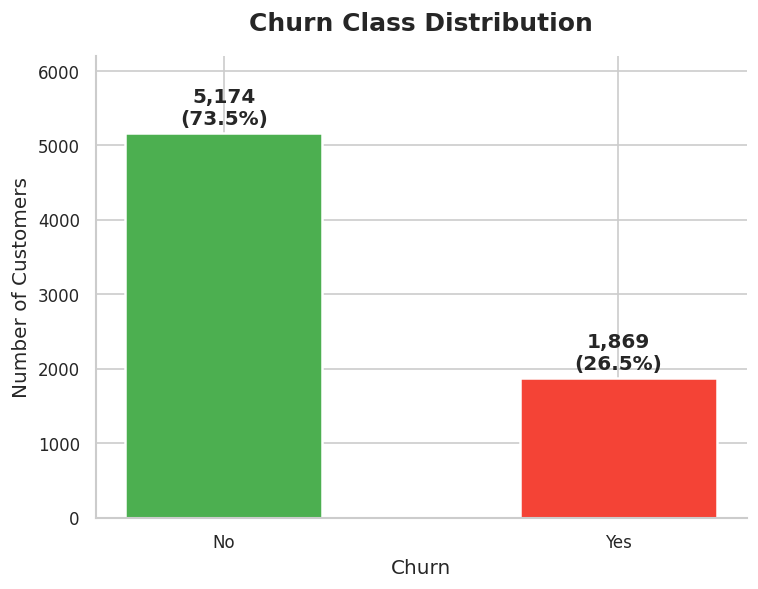

  ✅ Saved → outputs/plots/viz1_churn_distribution.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

churn_counts = df_raw['Churn'].value_counts()
churn_pct    = df_raw['Churn'].value_counts(normalize=True) * 100
colors = ['#4CAF50', '#F44336']

bars = ax.bar(churn_counts.index, churn_counts.values,
              color=colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, cnt, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60,
            f'{cnt:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Churn Class Distribution', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_ylim(0, churn_counts.max() * 1.20)
ax.spines[['top', 'right']].set_visible(False)
save_fig('viz1_churn_distribution.png')


### Visualization 2 — Contract Type vs Churn Rate
**Chart Type:** Grouped bar chart (hue=Churn)

Churn Rate by Contract Type:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%


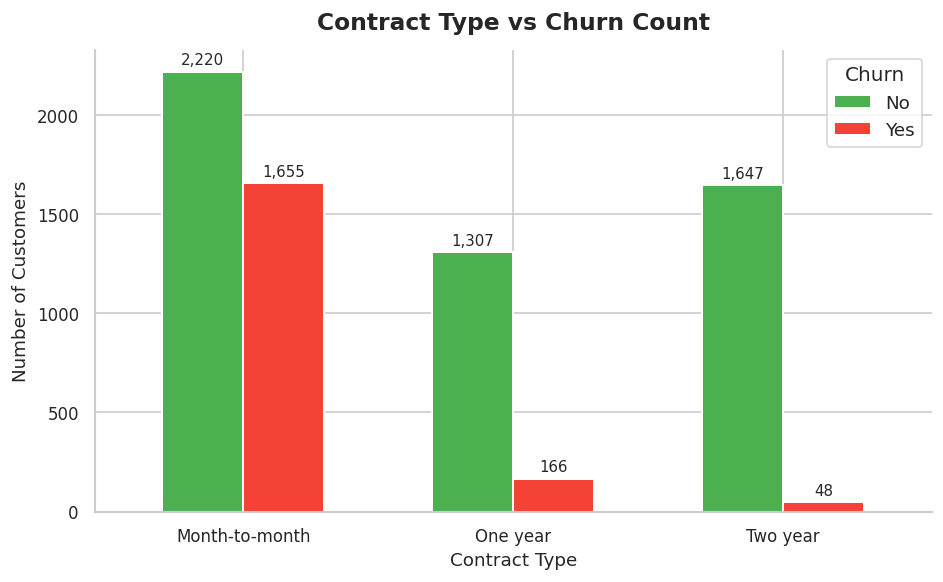

  ✅ Saved → outputs/plots/viz2_contract_vs_churn.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

contract_churn = (df_raw.groupby(['Contract', 'Churn'])
                        .size().reset_index(name='Count'))
pivot = contract_churn.pivot(index='Contract', columns='Churn',
                              values='Count').fillna(0)
pivot.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'],
           edgecolor='white', linewidth=1.2, width=0.6)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 20),
                ha='center', va='bottom', fontsize=9)

churn_rates = (df_raw.groupby('Contract')['Churn']
               .apply(lambda x: (x == 'Yes').mean() * 100))
print("Churn Rate by Contract Type:")
print(churn_rates.map('{:.1f}%'.format).to_string())

ax.set_title('Contract Type vs Churn Count', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Contract Type', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.legend(title='Churn', labels=['No', 'Yes'])
ax.spines[['top', 'right']].set_visible(False)
save_fig('viz2_contract_vs_churn.png')


### Visualization 3 — Tenure Distribution by Churn
**Chart Type:** Overlapping KDE histogram

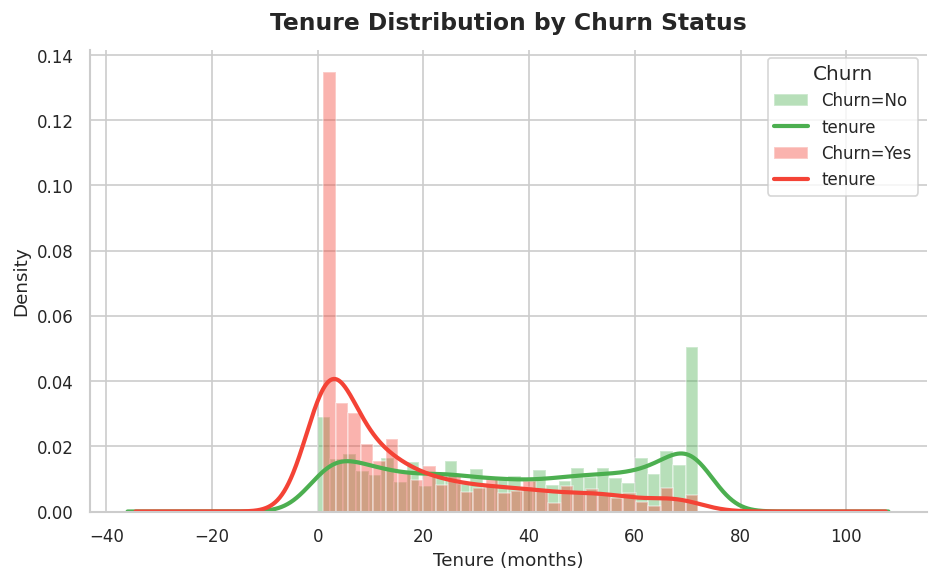

  ✅ Saved → outputs/plots/viz3_tenure_distribution.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, color in zip(['No', 'Yes'], ['#4CAF50', '#F44336']):
    subset = df_raw[df_raw['Churn'] == label]['tenure']
    ax.hist(subset, bins=30, alpha=0.4, color=color, density=True,
            label=f'Churn={label}')
    subset.plot.kde(ax=ax, color=color, linewidth=2.5)

ax.set_title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Tenure (months)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(title='Churn', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
save_fig('viz3_tenure_distribution.png')


### Visualization 4 — Churn Rate by Tenure Group (Line Chart)
**Chart Type:** Line chart with markers

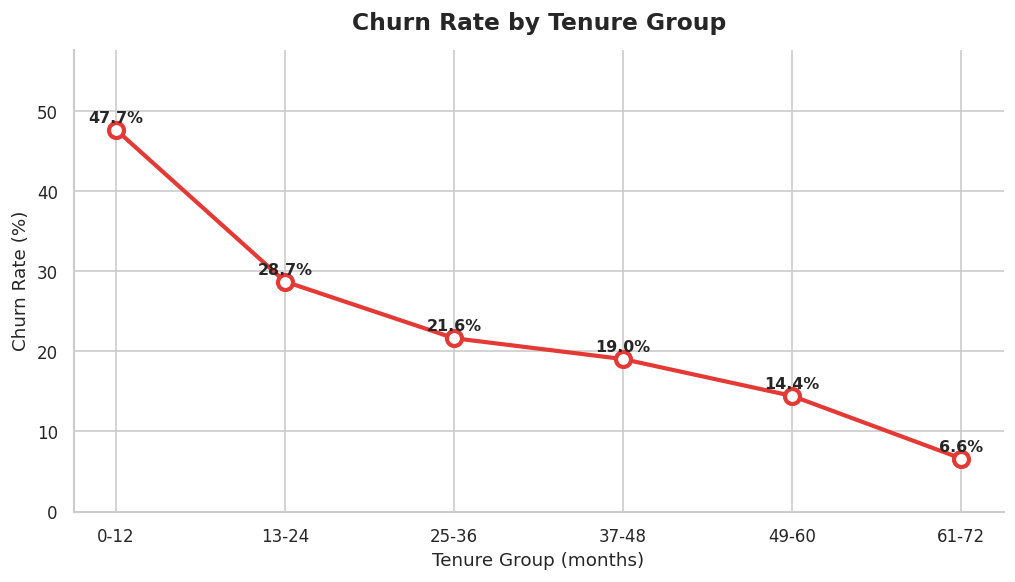

  ✅ Saved → outputs/plots/viz4_churn_by_tenure_group.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

df_temp = df_raw.copy()
df_temp['TenureGroup'] = pd.cut(df_temp['tenure'],
                                 bins=[0, 12, 24, 36, 48, 60, 72],
                                 labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])

tenure_churn = (df_temp.groupby('TenureGroup', observed=True)['Churn']
                        .apply(lambda x: (x == 'Yes').mean() * 100)
                        .reset_index(name='ChurnRate'))

ax.plot(tenure_churn['TenureGroup'].astype(str), tenure_churn['ChurnRate'],
        marker='o', color='#E53935', linewidth=2.5, markersize=9,
        markerfacecolor='white', markeredgewidth=2.5)

for _, row in tenure_churn.iterrows():
    ax.text(str(row['TenureGroup']), row['ChurnRate'] + 0.9,
            f"{row['ChurnRate']:.1f}%", ha='center', fontsize=9.5, fontweight='bold')

ax.set_title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Tenure Group (months)', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, tenure_churn['ChurnRate'].max() + 10)
ax.spines[['top', 'right']].set_visible(False)
save_fig('viz4_churn_by_tenure_group.png')


### Visualization 5 — Monthly Charges vs Churn (Violin Plot)
**Chart Type:** Violin + boxplot overlay

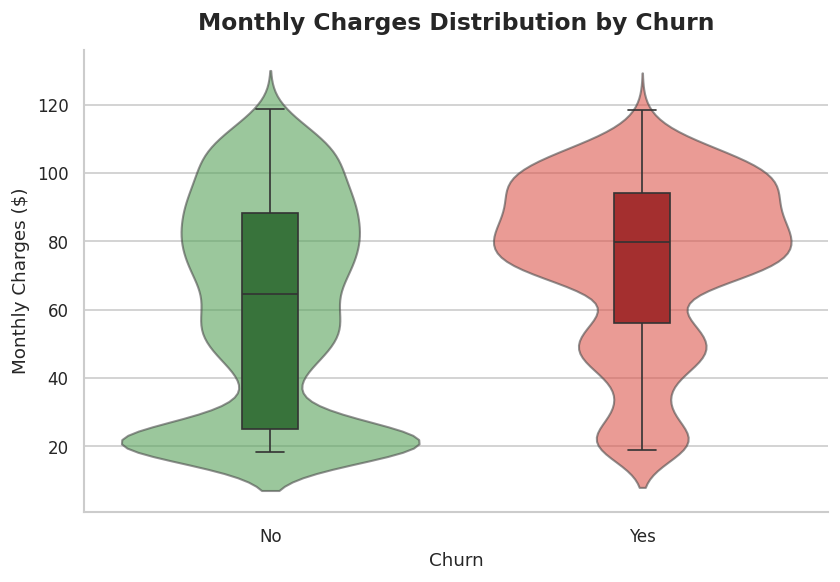

  ✅ Saved → outputs/plots/viz5_monthly_charges_violin.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(data=df_raw, x='Churn', y='MonthlyCharges',
               palette={'No': '#4CAF50', 'Yes': '#F44336'},
               inner=None, alpha=0.6, ax=ax)
sns.boxplot(data=df_raw, x='Churn', y='MonthlyCharges',
            width=0.15, palette={'No': '#2E7D32', 'Yes': '#B71C1C'},
            flierprops=dict(marker='o', markersize=3, alpha=0.5), ax=ax)

ax.set_title('Monthly Charges Distribution by Churn', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Churn', fontsize=11)
ax.set_ylabel('Monthly Charges ($)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
save_fig('viz5_monthly_charges_violin.png')


### Visualization 6 — Internet Service vs Churn
**Chart Type:** Grouped bar chart

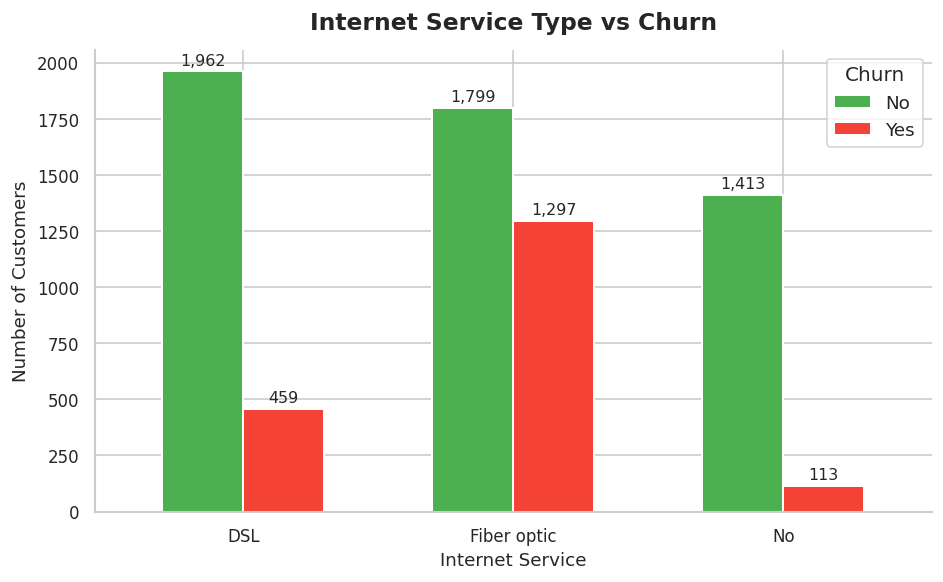

  ✅ Saved → outputs/plots/viz6_internet_service_vs_churn.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

inet_churn = (df_raw.groupby(['InternetService', 'Churn'])
                    .size().reset_index(name='Count'))
pivot_inet = inet_churn.pivot(index='InternetService', columns='Churn',
                               values='Count').fillna(0)
pivot_inet.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'],
                edgecolor='white', linewidth=1.2, width=0.6)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 15),
                ha='center', va='bottom', fontsize=9.5)

ax.set_title('Internet Service Type vs Churn', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Internet Service', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Churn', labels=['No', 'Yes'])
ax.spines[['top', 'right']].set_visible(False)
save_fig('viz6_internet_service_vs_churn.png')


### Visualization 7 — Payment Method vs Churn
**Chart Type:** Horizontal bar chart of churn rates

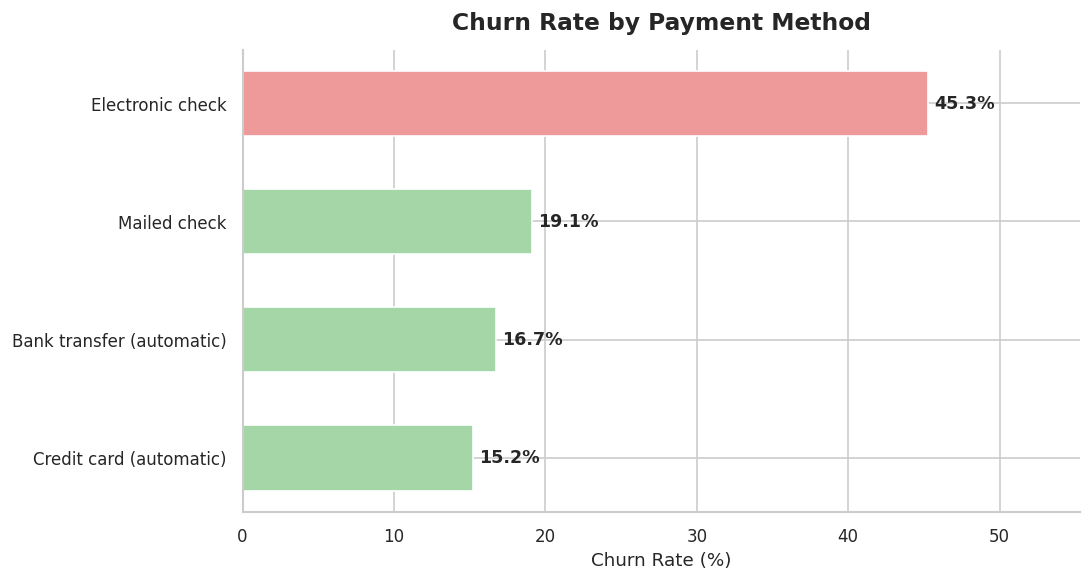

  ✅ Saved → outputs/plots/viz7_payment_method_churn_rate.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

pm_rate = (df_raw.groupby('PaymentMethod')['Churn']
                  .apply(lambda x: (x == 'Yes').mean() * 100)
                  .sort_values(ascending=True))

colors = ['#EF9A9A' if r > 30 else '#A5D6A7' for r in pm_rate.values]
bars = ax.barh(pm_rate.index, pm_rate.values, color=colors,
               edgecolor='white', height=0.55)

for bar, val in zip(bars, pm_rate.values):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10.5, fontweight='bold')

ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.set_xlim(0, pm_rate.max() + 10)
ax.spines[['top', 'right']].set_visible(False)
save_fig('viz7_payment_method_churn_rate.png')


### Visualization 8 — Correlation Heatmap of Numeric Features
**Chart Type:** Seaborn heatmap with annotations

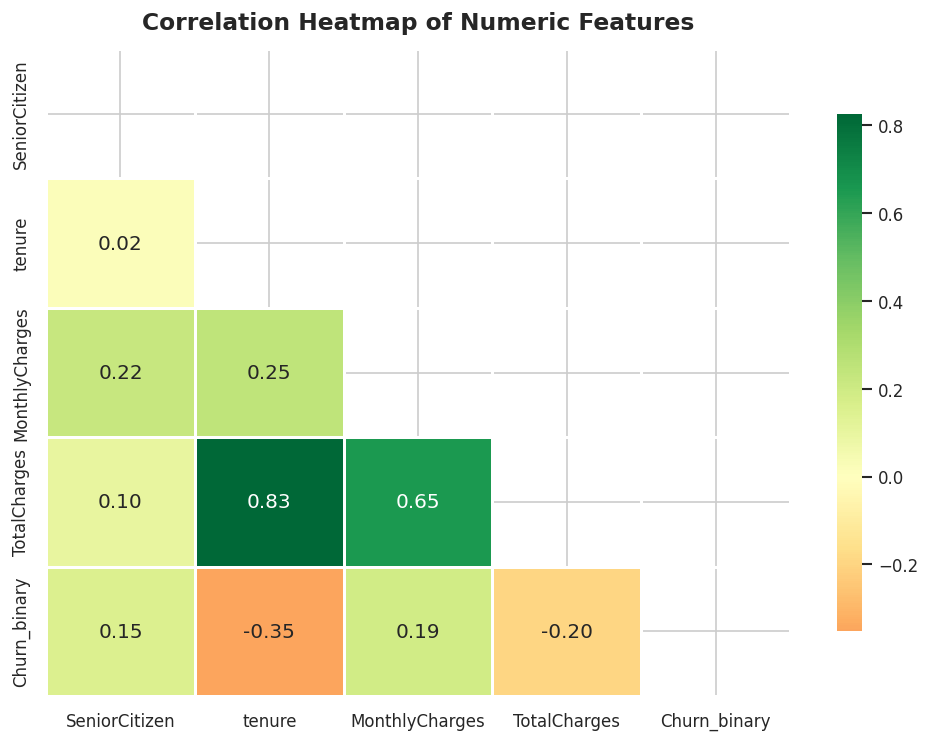

  ✅ Saved → outputs/plots/viz8_correlation_heatmap.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

df_num = df_raw.copy()
df_num['TotalCharges'] = pd.to_numeric(df_num['TotalCharges'], errors='coerce')
df_num['Churn_binary'] = (df_num['Churn'] == 'Yes').astype(int)
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
corr = df_num[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.8, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold', pad=12)
save_fig('viz8_correlation_heatmap.png')


### Visualization 9 — Churn Heatmap — Tenure vs Monthly Charges
**Chart Type:** 2D heatmap density grid

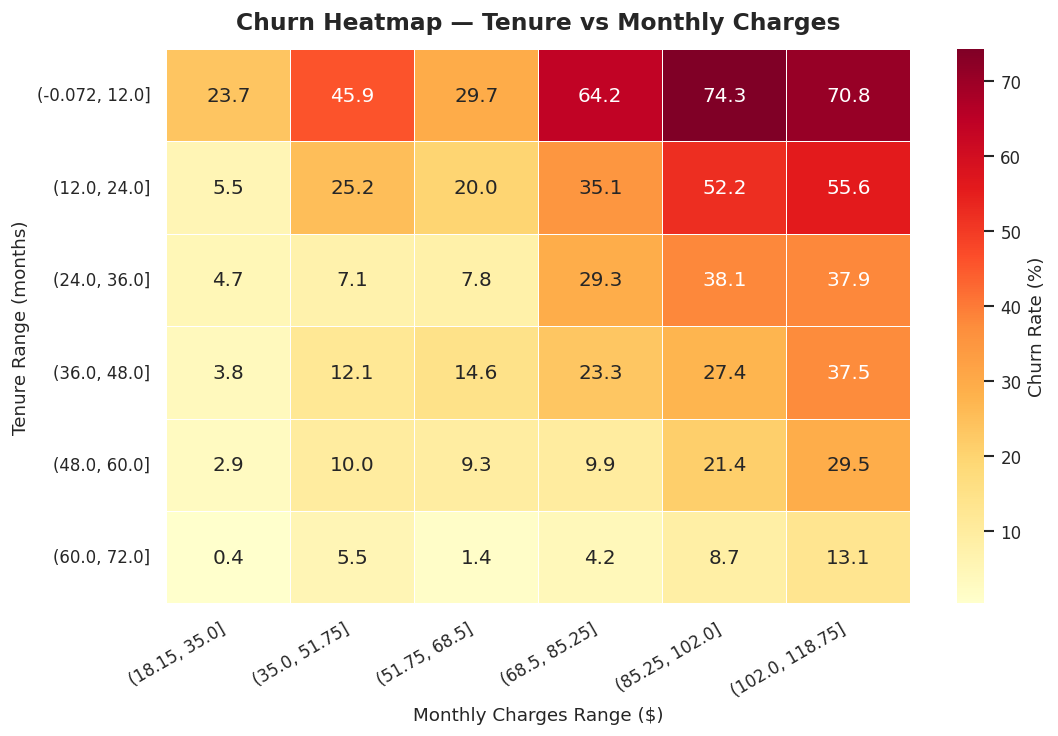

  ✅ Saved → outputs/plots/viz9_churn_heatmap_tenure_charges.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

df_h = df_raw.copy()
df_h['TenureBin']  = pd.cut(df_h['tenure'], bins=6)
df_h['ChargesBin'] = pd.cut(df_h['MonthlyCharges'], bins=6)
df_h['Churn_bin']  = (df_h['Churn'] == 'Yes').astype(int)

heatmap_data = (df_h.groupby(['TenureBin', 'ChargesBin'], observed=True)['Churn_bin']
                     .mean() * 100).unstack()

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Churn Rate (%)'})

ax.set_title('Churn Heatmap — Tenure vs Monthly Charges', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Monthly Charges Range ($)', fontsize=11)
ax.set_ylabel('Tenure Range (months)', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
save_fig('viz9_churn_heatmap_tenure_charges.png')


### Visualization 10 — Senior Citizen Churn Comparison
**Chart Type:** Side-by-side pie charts

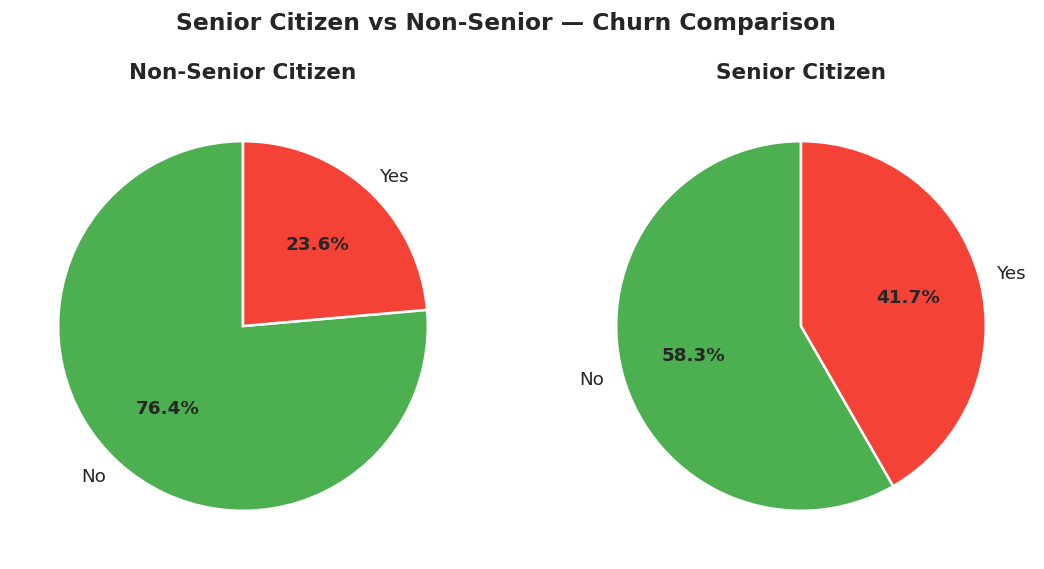

  ✅ Saved → outputs/plots/viz10_senior_citizen_churn_pie.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (sc_val, label) in zip(axes,
        [(0, 'Non-Senior Citizen'), (1, 'Senior Citizen')]):
    subset = df_raw[df_raw['SeniorCitizen'] == sc_val]['Churn'].value_counts()
    wedges, texts, autotexts = ax.pie(
        subset.values, labels=subset.index, autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'], startangle=90,
        textprops={'fontsize': 11},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    for at in autotexts:
        at.set_fontweight('bold')
    ax.set_title(label, fontsize=13, fontweight='bold', pad=10)

fig.suptitle('Senior Citizen vs Non-Senior — Churn Comparison',
             fontsize=14, fontweight='bold', y=1.02)
save_fig('viz10_senior_citizen_churn_pie.png')


### Visualization 11 — Tech Support & Online Security Impact
**Chart Type:** 2×2 grouped bar grid

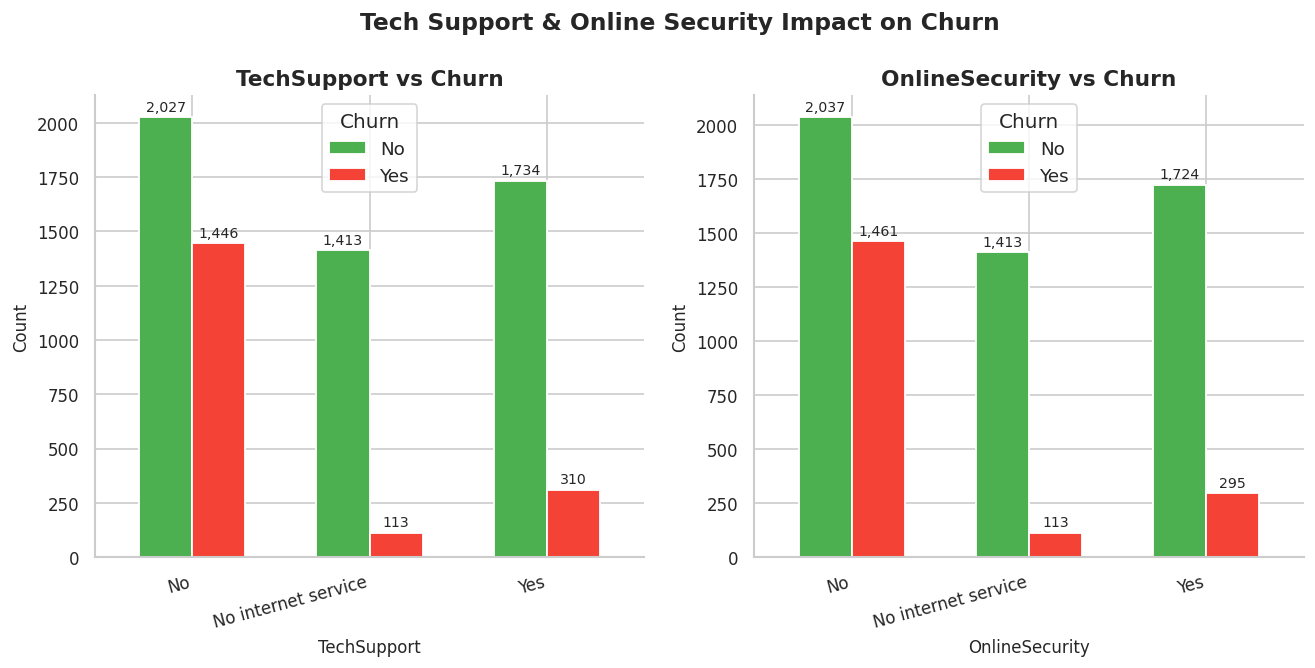

  ✅ Saved → outputs/plots/viz11_techsupport_security_churn.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ['TechSupport', 'OnlineSecurity']):
    data = (df_raw.groupby([col, 'Churn']).size().reset_index(name='Count'))
    pivot = data.pivot(index=col, columns='Churn', values='Count').fillna(0)
    pivot.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'],
               edgecolor='white', linewidth=1.1, width=0.6)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2, p.get_height() + 15),
                    ha='center', va='bottom', fontsize=8.5)
    ax.set_title(f'{col} vs Churn', fontsize=13, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
    ax.legend(title='Churn', labels=['No', 'Yes'])
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Tech Support & Online Security Impact on Churn',
             fontsize=14, fontweight='bold', y=1.02)
save_fig('viz11_techsupport_security_churn.png')


## Step 3 — Preprocessing (preprocess_data)

In [ ]:
def preprocess_data(df):
    """Clean, encode, and split the raw dataframe into X and y."""
    df = df.copy()

    # Drop rows with any missing values as they are few and spread across many columns.
    df = df.dropna()

    # Drop customerID
    df = df.drop(columns=['customerID'])

    # Fix TotalCharges: string -> float -> fill median (Copy-on-Write safe)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    tc_median = df['TotalCharges'].median()
    df['TotalCharges'] = df['TotalCharges'].fillna(tc_median)

    # Verify no NaNs remain
    assert df['TotalCharges'].isna().sum() == 0, "TotalCharges still has NaN!"

    # Map target
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

    # Map binary Yes/No columns
    binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    for col in binary_cols:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    # One-hot encode remaining categorical columns
    cat_cols = ['gender', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

    # Convert bool columns to int (required by SMOTE)
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    # Separate features and target
    y = df['Churn']
    X = df.drop(columns=['Churn'])

    # Final NaN check
    assert X.isna().sum().sum() == 0, f"X still has NaN: {X.isna().sum()[X.isna().sum()>0]}"

    print(f"✅  Preprocessing complete.")
    print(f"   Feature matrix shape : {X.shape}")
    print(f"   Target vector shape  : {y.shape}")
    print(f"   Churn=1 count        : {y.sum()} ({y.mean()*100:.1f}%)")

    return X, y


X, y = preprocess_data(df_raw)
print("\nSample feature columns:")
print(list(X.columns[:15]), '...')

✅  Preprocessing complete.
   Feature matrix shape : (7043, 41)
   Target vector shape  : (7043,)
   Churn=1 count        : 1869 (26.5%)

Sample feature columns:
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'gender_Female', 'gender_Male', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic'] ...


## Step 4 — Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set   : {X_train.shape[0]} rows")
print(f"Test set       : {X_test.shape[0]} rows")
print(f"Train churn %  : {y_train.mean()*100:.1f}%")
print(f"Test  churn %  : {y_test.mean()*100:.1f}%")


Training set   : 5634 rows
Test set       : 1409 rows
Train churn %  : 26.5%
Test  churn %  : 26.5%


## Step 5 — Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅  StandardScaler fitted on {X_train_sc.shape[1]} features.")
print(f"   Train mean range : {X_train_sc.mean(axis=0).min():.4f} – {X_train_sc.mean(axis=0).max():.4f}")
print(f"   Train std  range : {X_train_sc.std(axis=0).min():.4f} – {X_train_sc.std(axis=0).max():.4f}")


✅  StandardScaler fitted on 41 features.
   Train mean range : -0.0000 – 0.0000
   Train std  range : 1.0000 – 1.0000


## Step 6 — Class Imbalance Handling (SMOTE)

✅  SMOTE applied.
   Before → Churn=0: 4139  |  Churn=1: 1495
   After  → Churn=0: 4139  |  Churn=1: 4139


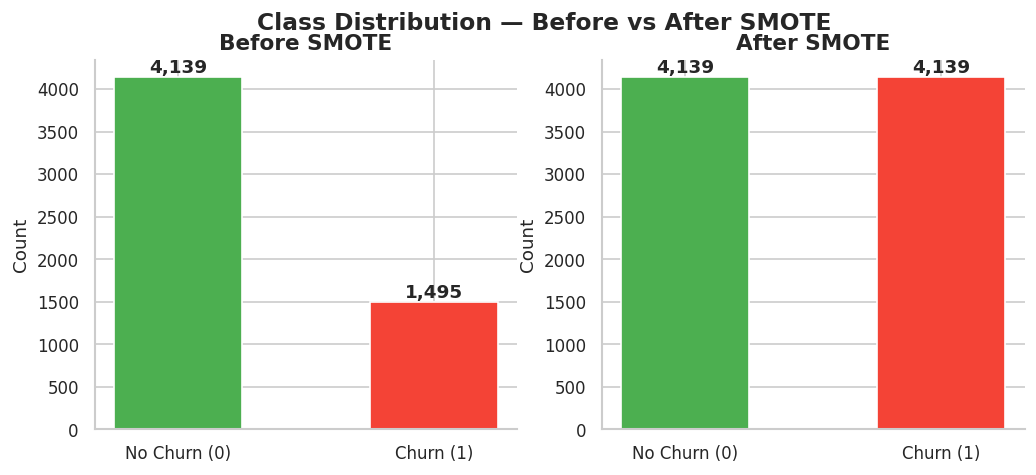

  ✅ Saved → outputs/plots/viz_smote_balance.png


In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print(f"✅  SMOTE applied.")
print(f"   Before → Churn=0: {(y_train==0).sum()}  |  Churn=1: {(y_train==1).sum()}")
print(f"   After  → Churn=0: {(y_train_res==0).sum()}  |  Churn=1: {(y_train_res==1).sum()}")

# Bar chart: before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (counts, title) in zip(axes, [
    (pd.Series(y_train).value_counts().sort_index(), 'Before SMOTE'),
    (pd.Series(y_train_res).value_counts().sort_index(), 'After SMOTE')]):
    ax.bar(['No Churn (0)', 'Churn (1)'], counts.values,
           color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Class Distribution — Before vs After SMOTE', fontsize=14, fontweight='bold')
save_fig('viz_smote_balance.png')


## Step 7 — Model Training

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, random_state=42, class_weight='balanced'),

    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=7, random_state=42, class_weight='balanced'),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5,
        random_state=42, eval_metric='logloss')
}

trained_models = {}
for name, model in models.items():
    print(f"  Training {name}...", end=' ', flush=True)
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print("done ✅")

print("\n✅  All 4 models trained successfully.")


  Training Logistic Regression... done ✅
  Training Decision Tree... done ✅
  Training Random Forest... done ✅
  Training XGBoost... done ✅

✅  All 4 models trained successfully.


## Step 8 — Evaluation

  Logistic Regression
  Accuracy  : 0.7388
  ROC-AUC   : 0.8406

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



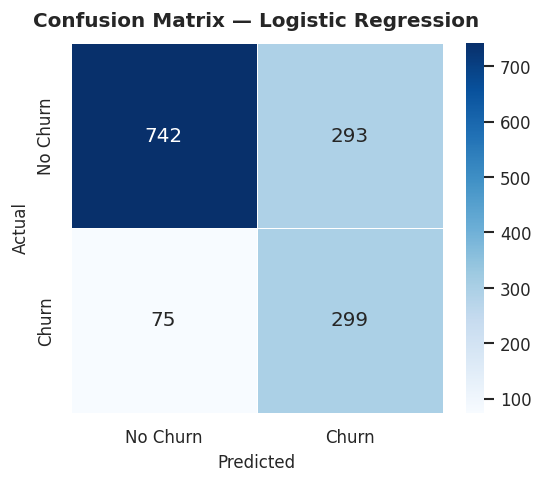

  ✅ Saved → outputs/plots/confusion_matrix_logistic_regression.png
  Decision Tree
  Accuracy  : 0.7246
  ROC-AUC   : 0.8121

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.72      0.79      1035
       Churn       0.49      0.75      0.59       374

    accuracy                           0.72      1409
   macro avg       0.69      0.73      0.69      1409
weighted avg       0.78      0.72      0.74      1409



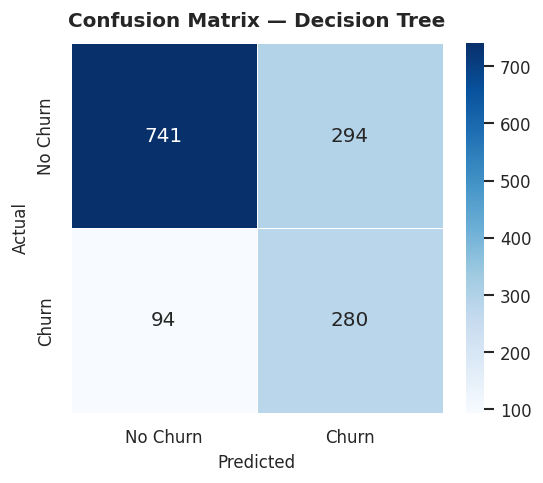

  ✅ Saved → outputs/plots/confusion_matrix_decision_tree.png
  Random Forest
  Accuracy  : 0.7615
  ROC-AUC   : 0.8393

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



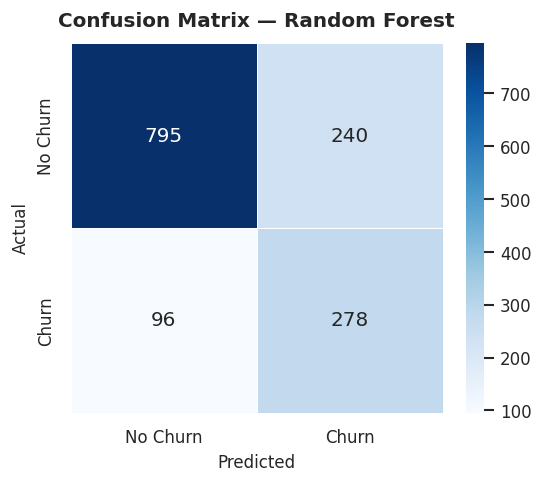

  ✅ Saved → outputs/plots/confusion_matrix_random_forest.png
  XGBoost
  Accuracy  : 0.7807
  ROC-AUC   : 0.8390

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.83      0.85      1035
       Churn       0.58      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



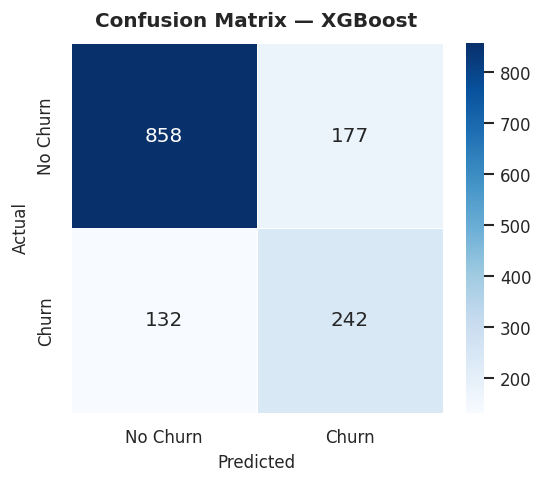

  ✅ Saved → outputs/plots/confusion_matrix_xgboost.png


In [ ]:
results = {}

for name, model in trained_models.items():
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)

    y_pred      = model.predict(X_test_sc)
    y_pred_prob = model.predict_proba(X_test_sc)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    # Confusion Matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=0.5, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    fname = name.lower().replace(' ', '_')
    save_fig(f'confusion_matrix_{fname}.png')

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    results[name] = {
        'accuracy': acc, 'roc_auc': roc_auc,
        'fpr': fpr, 'tpr': tpr, 'model': model
    }


### Visualization 12 — All 4 ROC Curves on One Chart
**Chart Type:** Multi-line ROC curve comparison

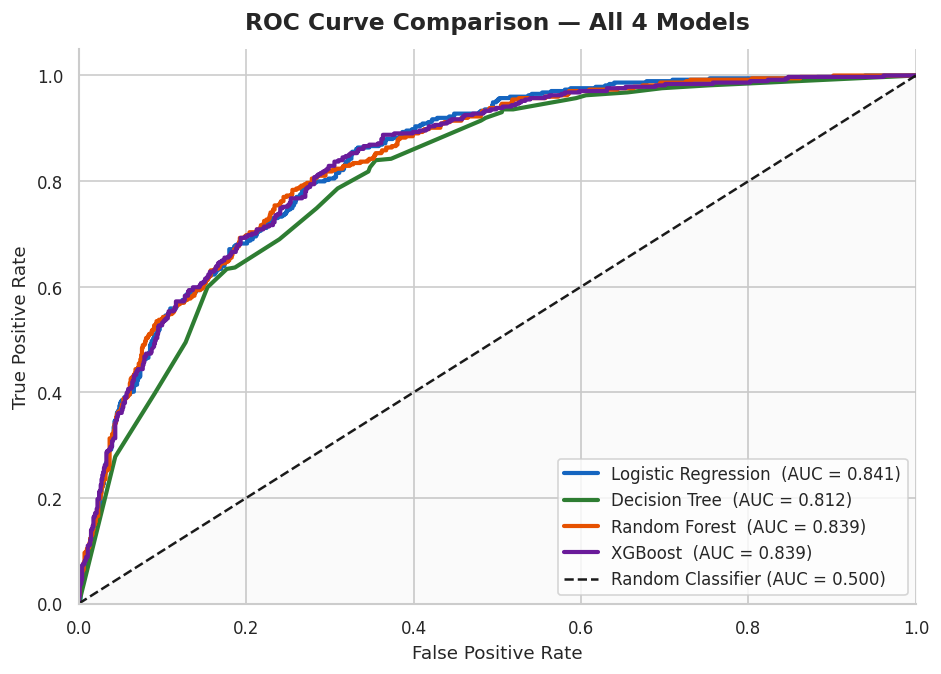

  ✅ Saved → outputs/plots/viz12_roc_curves_all_models.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

palette = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
for (name, res), color in zip(results.items(), palette):
    ax.plot(res['fpr'], res['tpr'], lw=2.5, color=color,
            label=f"{name}  (AUC = {res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
ax.set_title('ROC Curve Comparison — All 4 Models', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.spines[['top', 'right']].set_visible(False)
save_fig('viz12_roc_curves_all_models.png')


### Model Performance Summary


       MODEL PERFORMANCE SUMMARY


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.7388,0.8406
1,Decision Tree,0.7246,0.8121
2,Random Forest,0.7615,0.8393
3,XGBoost,0.7807,0.8390


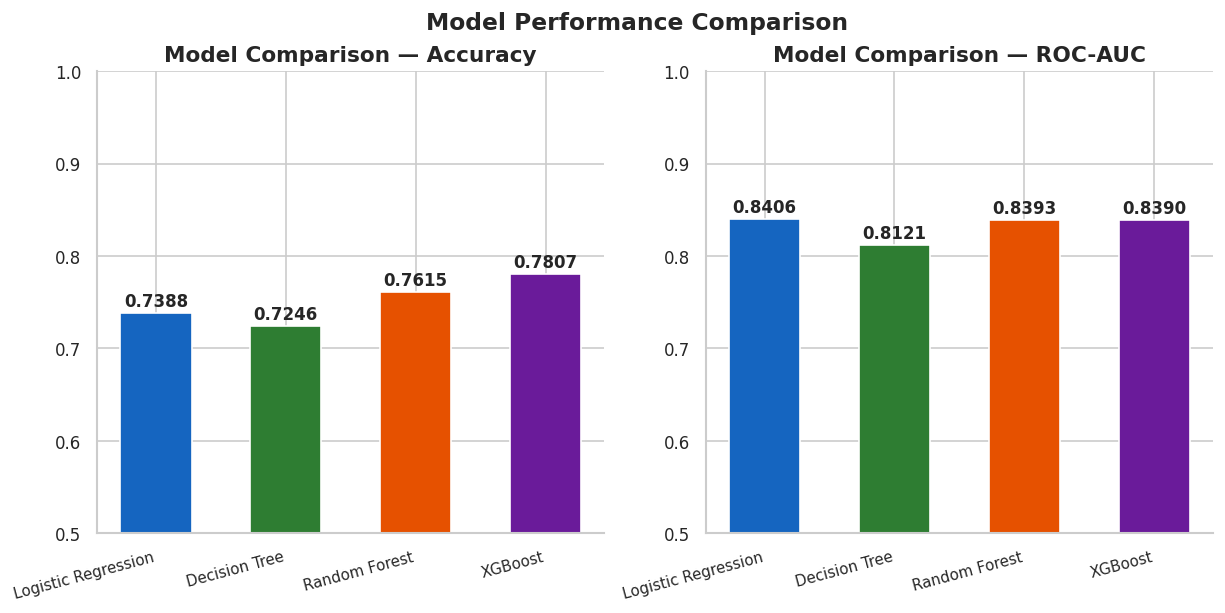

  ✅ Saved → outputs/plots/model_comparison_bar.png


In [ ]:
summary_df = pd.DataFrame({
    name: {'Accuracy': res['accuracy'], 'ROC-AUC': res['roc_auc']}
    for name, res in results.items()
}).T.reset_index().rename(columns={'index': 'Model'})

print("\n" + "=" * 55)
print("       MODEL PERFORMANCE SUMMARY")
print("=" * 55)
display(summary_df.round(4))
print("=" * 55)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette_bar = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
for ax, metric in zip(axes, ['Accuracy', 'ROC-AUC']):
    names_ = summary_df['Model'].tolist()
    vals_  = summary_df[metric].tolist()
    bars   = ax.bar(names_, vals_, color=palette_bar, edgecolor='white', width=0.55)
    for bar, val in zip(bars, vals_):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'Model Comparison — {metric}', fontsize=13, fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.set_xticklabels(names_, rotation=15, ha='right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
save_fig('model_comparison_bar.png')


## Step 9 — Best Model & Feature Importance

In [ ]:
best_name  = max(results, key=lambda n: results[n]['roc_auc'])
best_model = results[best_name]['model']

print(f"🏆  Best Model : {best_name}")
print(f"   ROC-AUC   : {results[best_name]['roc_auc']:.4f}")
print(f"   Accuracy  : {results[best_name]['accuracy']:.4f}")


🏆  Best Model : Logistic Regression
   ROC-AUC   : 0.8406
   Accuracy  : 0.7388


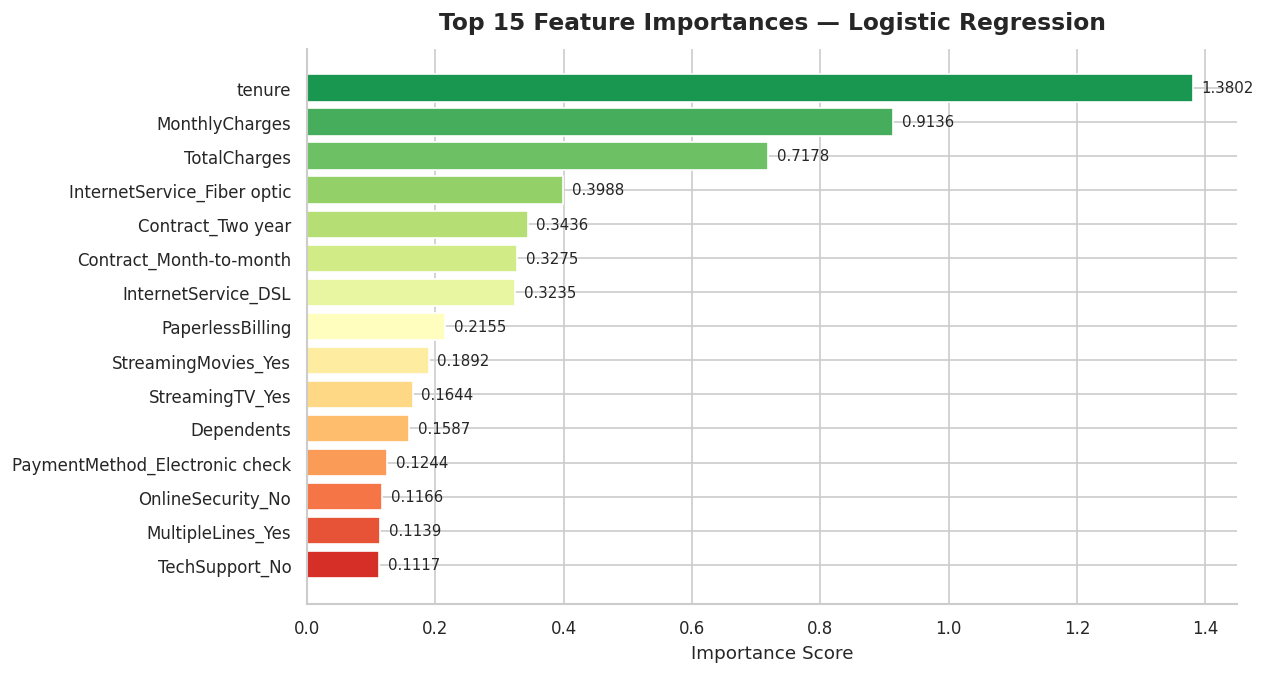

  ✅ Saved → outputs/plots/viz_feature_importance.png


In [ ]:
# Feature importance — top 15
feature_names = X.columns.tolist()

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = np.ones(len(feature_names))

fi_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
           .sort_values('Importance', ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
colors_ = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(fi_df)))
bars = ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
               color=colors_[::-1], edgecolor='white')

for bar, val in zip(bars, fi_df['Importance'][::-1]):
    ax.text(val + fi_df['Importance'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title(f'Top 15 Feature Importances — {best_name}',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
save_fig('viz_feature_importance.png')


In [ ]:
# Save best model and scaler
joblib.dump(best_model, 'outputs/models/best_model.pkl')
joblib.dump(scaler,     'outputs/models/scaler.pkl')

print(f"✅  best_model.pkl → outputs/models/best_model.pkl")
print(f"✅  scaler.pkl     → outputs/models/scaler.pkl")

# Reload and sanity check
reloaded = joblib.load('outputs/models/best_model.pkl')
preds    = reloaded.predict(X_test_sc[:5])
print(f"\nReload sanity check — first 5 predictions: {preds.tolist()}")
print("\n🎉  Pipeline complete. All outputs saved to outputs/")


✅  best_model.pkl → outputs/models/best_model.pkl
✅  scaler.pkl     → outputs/models/scaler.pkl

Reload sanity check — first 5 predictions: [0, 1, 0, 1, 0]

🎉  Pipeline complete. All outputs saved to outputs/


In [ ]:
import gradio as gr
import pandas as pd
import joblib
import os
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # Import StandardScaler for explicit loading

# Define paths for the saved classifier and scaler
classifier_path = 'outputs/models/best_model.pkl'
scaler_path = 'outputs/models/scaler.pkl'

# ---------- 1. Load the pre-trained pipeline components ----------
# Check if both classifier and scaler exist
if not os.path.exists(classifier_path) or not os.path.exists(scaler_path):
    print("⚠️ Pre-trained classifier or scaler not found. Please ensure all previous cells (especially model training and saving) have been executed.")
    raise FileNotFoundError("Required model components (classifier or scaler) not found.")

# Load the trained classifier and the scaler
best_classifier = joblib.load(classifier_path)
loaded_scaler = joblib.load(scaler_path)

# Construct the full prediction pipeline
# This pipeline will first scale the numerical features, then apply the classifier.
pipeline = Pipeline([
    ('scaler', loaded_scaler),
    ('classifier', best_classifier)
])

print("✅ Prediction pipeline loaded successfully.")

# ---------- 2. Get the expected column order from training data ----------
# This should be X_train's columns *after* one-hot encoding but *before* scaling.
# X_train is available globally from previous cells after preprocessing.
try:
    expected_cols = X_train.columns.tolist()
except NameError:
    # This fallback is crucial for standalone execution if X_train is not in memory.
    # This list needs to EXACTLY match the columns created by `preprocess_data` function.
    expected_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
                     'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
                     'gender_Female', 'gender_Male', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes',
                     'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No',
                     'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
                     'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes',
                     'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes',
                     'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
                     'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
                     'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes',
                     'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
                     'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)',
                     'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
    print("⚠️ X_train not found in memory. Using hardcoded expected_cols. Please verify its accuracy if running standalone.")


# ---------- 3. Prediction function ----------
# The `predict_churn` function must mirror the `preprocess_data` function's transformations.
def predict_churn(tenure, monthly, contract, internet, payment, senior, gender,
                  partner, dependents, phone, multiple_lines, paperless,
                  online_security, online_backup, device_protection, tech_support,
                  streaming_tv, streaming_movies):

    # Create a raw input DataFrame structure similar to `df_raw` (without customerID)
    input_data = {
        # Numerical features
        'SeniorCitizen': float(senior), # Gradio inputs 0/1, convert to float
        'tenure': float(tenure),
        'MonthlyCharges': float(monthly),
        'TotalCharges': str(round(tenure * monthly, 2)), # Approx total as string for preproc consistency

        # Binary Yes/No columns (Gradio inputs are 1/0, convert to 'Yes'/'No' strings for mapping)
        'Partner': 'Yes' if partner == 1 else 'No',
        'Dependents': 'Yes' if dependents == 1 else 'No',
        'PhoneService': 'Yes' if phone == 1 else 'No',
        'PaperlessBilling': 'Yes' if paperless == 1 else 'No',

        # Categorical columns
        'gender': gender, # 'Male', 'Female'
        'MultipleLines': multiple_lines, # 'No', 'Yes', 'No phone service'
        'InternetService': internet, # 'DSL', 'Fiber optic', 'No'
        'OnlineSecurity': online_security, # 'No', 'Yes', 'No internet service'
        'OnlineBackup': online_backup,
        'DeviceProtection': device_protection,
        'TechSupport': tech_support,
        'StreamingTV': streaming_tv,
        'StreamingMovies': streaming_movies,
        'Contract': contract, # 'Month-to-month', 'One year', 'Two year'
        'PaymentMethod': payment, # e.g. 'Electronic check'
    }
    # Create DataFrame from input data for processing
    input_df = pd.DataFrame([input_data])

    # --- Replicate `preprocess_data` steps on `input_df` ---

    # 1. TotalCharges: string -> float -> fill median (if any NaN from conversion)
    input_df['TotalCharges'] = pd.to_numeric(input_df['TotalCharges'], errors='coerce')
    # Assuming valid numeric input here so no NaN will be created for TotalCharges.

    # 2. Map binary Yes/No columns to 1/0
    binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    for col in binary_cols:
        input_df[col] = input_df[col].map({'Yes': 1, 'No': 0})

    # 3. One-hot encode remaining categorical columns
    cat_cols = ['gender', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaymentMethod']

    # Apply one-hot encoding
    input_df_encoded = pd.get_dummies(input_df, columns=cat_cols, drop_first=False)

    # 4. Convert bool columns (created by get_dummies) to int
    bool_cols = input_df_encoded.select_dtypes(include='bool').columns
    input_df_encoded[bool_cols] = input_df_encoded[bool_cols].astype(int)

    # Align columns with the `expected_cols` from training data
    # Add missing columns (from training data) to `input_df_encoded` and fill with 0
    missing_from_input = set(expected_cols) - set(input_df_encoded.columns)
    for c in missing_from_input:
        input_df_encoded[c] = 0

    # Drop columns in `input_df_encoded` that are not in `expected_cols`
    extra_in_input = set(input_df_encoded.columns) - set(expected_cols)
    if extra_in_input:
        input_df_encoded = input_df_encoded.drop(columns=list(extra_in_input))

    # Ensure the order of columns matches `expected_cols`
    input_df_final = input_df_encoded[expected_cols]

    # Predict using the loaded pipeline (which handles scaling)
    prob = pipeline.predict_proba(input_df_final)[0][1]
    return f"Churn risk: {prob:.1%} – {'⚠️ High' if prob > 0.5 else '✅ Low'}"


# ---------- 4. Gradio interface ----------
inputs = [
    gr.Slider(0, 72, value=12, label="Tenure (months)"),
    gr.Slider(20, 120, value=70, label="Monthly Charges ($)"),
    gr.Dropdown(['Month-to-month', 'One year', 'Two year'], label="Contract"),
    gr.Dropdown(['DSL', 'Fiber optic', 'No'], label="Internet Service"),
    gr.Dropdown(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], label="Payment Method"),
    gr.Dropdown([0, 1], label="Senior Citizen", info="0 for No, 1 for Yes"),
    gr.Dropdown(['Male', 'Female'], label="Gender"),
    gr.Dropdown([1, 0], label="Partner", info="1 for Yes, 0 for No"),
    gr.Dropdown([1, 0], label="Dependents", info="1 for Yes, 0 for No"),
    gr.Dropdown([1, 0], label="Phone Service", info="1 for Yes, 0 for No"),
    gr.Dropdown(['No', 'Yes', 'No phone service'], label="Multiple Lines"),
    gr.Dropdown([1, 0], label="Paperless Billing", info="1 for Yes, 0 for No"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Online Security"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Online Backup"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Device Protection"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Tech Support"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Streaming TV"),
    gr.Dropdown(['No', 'Yes', 'No internet service'], label="Streaming Movies"),
]
output = gr.Textbox(label="Prediction Result")

gr.Interface(
    fn=predict_churn,
    inputs=inputs,
    outputs=output,
    title="📊 Telco Customer Churn Predictor",
    description="Enter customer details to estimate the probability of churn. All fields are required.",
    theme="compact"
).launch(share=True)

✅ Prediction pipeline loaded successfully.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d3cd50087cb2d85e9e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
